In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
import matplotlib.pyplot as plt
import forestplot as fp

In [8]:
data_path = Path(ROOT / 'data' / 'logistic_coefficients' / 'logistic_coef_results.csv')
df = pd.read_csv(data_path)

In [55]:
cols = [c for c in df.columns if c != 'odds_ratios']
print(cols)
pivoted = df.pivot(
    index='feature_names',
    columns='year',
    values=['odds_ratios', 'pvalues', 'confidence_lower', 'confidence_upper', 'std_error']
)
pivoted.head()

['feature_names', 'pvalues', 'confidence_lower', 'confidence_upper', 'std_error', 'year']


odds_ratios                                                    \
year              2016/17   2017/18   2018/19   2019/20   2020/21   2021/22   
feature_names                                                                 
Disab3_2.0       1.714241  1.715658  1.414873  1.574216  1.776679  1.629798   
Disab3_3.0       1.539972  1.570497  1.387132  1.341730  1.416094  1.311662   
Eth7_2.0         0.701127  0.691661  0.706015  0.724591  0.770211  0.787968   
Eth7_3.0         0.382414  0.417750  0.351837  0.387627  0.467485  0.490074   
Eth7_4.0         0.452637  0.430814  0.506147  0.402292  0.446599  0.458082   

                              pvalues                              ...  \
year            2022/23       2016/17       2017/18       2018/19  ...   
feature_names                                                      ...   
Disab3_2.0     1.557407  2.045489e-12  6.606510e-10  1.816271e-05  ...   
Disab3_3.0     1.330185  3.948261e-12  1.687850e-10  7.453031e-07  ...   
Eth7_2.0       0.814706  3.871155e-10  1.888021e-09  2.831495e-08  ...   
Eth7_3.0       0.482837  1.516094e-57  3.217715e-38  1.163202e-56  ...   
Eth7_4.0       0.494981  4.796087e-23  8.691397e-22  1.067789e-13  ...   

              confidence_upper                     std_error            \
year                   2020/21   2021/22   2022/23   2016/17   2017/18   
feature_names                                                            
Disab3_2.0            2.075238  1.905546  1.819112  0.076653  0.087413   
Disab3_3.0            1.604949  1.481269  1.501579  0.062223  0.070670   
Eth7_2.0              0.864504  0.888020  0.918571  0.056728  0.061370   
Eth7_3.0              0.526336  0.552202  0.544747  0.060118  0.067529   
Eth7_4.0              0.527983  0.542217  0.584678  0.080182  0.087795   

                                                                 
year            2018/19   2019/20   2020/21   2021/22   2022/23  
feature_names                                                    
Disab3_2.0     0.080964  0.093409  0.079251  0.079753  0.079249  
Disab3_3.0     0.066120  0.074579  0.063874  0.062044  0.061837  
Eth7_2.0       0.062707  0.066314  0.058925  0.060989  0.061221  
Eth7_3.0       0.065855  0.067936  0.060497  0.060897  0.061553  
Eth7_4.0       0.091618  0.097398  0.085411  0.086031  0.084972  

[5 rows x 35 columns]

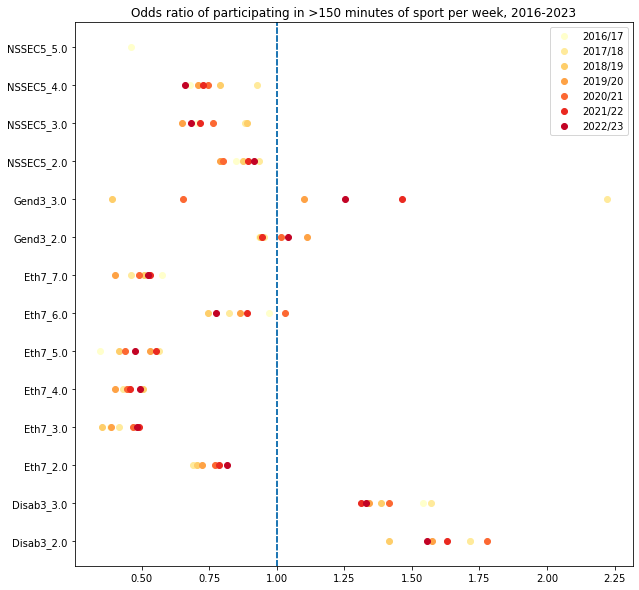

In [89]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_prop_cycle(color = plt.cm.YlOrRd(np.linspace(0,1,8)))
for idx, year in enumerate(sorted(df['year'].unique())):
    ax.errorbar(x=pivoted['odds_ratios'][year].values, y =pivoted.index, marker='o', linestyle='None', label=year)
    ax.legend()
    ax.set_title('Odds ratio of participating in >150 minutes of sport per week, 2016-2023')
    ax.axvline(x=1, linestyle='--')

